In [7]:
# Cell 1: Imports & Setup
import sys
import os
import importlib

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import core.knn
importlib.reload(core.knn)
from core.knn import get_knn

print("Setup complete.")

Setup complete.


In [8]:
# Cell 2: Weighted KNN Model
class WeightedKNN(nn.Module):
    def __init__(self, num_classes=2):
        super(WeightedKNN, self).__init__()
        self.num_classes = num_classes

    def forward(self, query, neighbors, neighbor_labels):
        """
        query: (batch_size, dim)
        neighbors: (batch_size, K, dim)
        neighbor_labels: (batch_size, K)
        """
        # cosine similarity between query and each neighbor
        q = F.normalize(query, p=2, dim=-1)                     # (B, D)
        n = F.normalize(neighbors, p=2, dim=-1)                 # (B, K, D)
        sim = torch.sum(n * q.unsqueeze(1), dim=-1)             # (B, K)

        # make weights positive and normalized
        weights = torch.softmax(sim, dim=1)                     # (B, K)

        one_hot = F.one_hot(neighbor_labels, num_classes=self.num_classes).float()   # (B, K, C)
        output = torch.sum(one_hot * weights.unsqueeze(-1), dim=1)                   # (B, C)

        return output, weights

In [9]:
# Cell 3: Train / Evaluate for Weighted KNN
def train(model, X_train, y_train, optimizer, loss_fn, K):
    model.train()
    total_loss = 0.0

    with torch.no_grad():
        for i in range(len(X_train)):
            x = X_train[i]
            y = y_train[i]

            neighbors, labels = get_knn(x, X_train, y_train, K)

            x = x.unsqueeze(0)
            neighbors = neighbors.unsqueeze(0)
            labels = labels.unsqueeze(0)

            pred, _ = model(x, neighbors, labels)
            loss = loss_fn(torch.log(pred + 1e-12), y.unsqueeze(0))

            total_loss += loss.item()

    return total_loss / len(X_train)


def evaluate(model, X_test, y_test, X_train, y_train, K):
    model.eval()
    correct = 0

    with torch.no_grad():
        for i in range(len(X_test)):
            x = X_test[i]
            y = y_test[i]

            neighbors, labels = get_knn(x, X_train, y_train, K)

            x = x.unsqueeze(0)
            neighbors = neighbors.unsqueeze(0)
            labels = labels.unsqueeze(0)

            pred, _ = model(x, neighbors, labels)

            if pred.argmax(dim=1).item() == y.item():
                correct += 1

    return correct / len(X_test)

In [10]:
# Cell 4: Experiment Runner
def run_experiment(
    X_train, X_test, y_train, y_test,
    input_dim, num_classes,
    experiment_name="experiment",
    K=5,
    epochs=20
):
    print(f"\n{'='*60}")
    print(f"Experiment: {experiment_name}")
    print(f"Input dim: {input_dim}")
    print(f"Classes: {num_classes}")
    print(f"K: {K}")
    print(f"{'='*60}")

    model = WeightedKNN(num_classes=num_classes)

    optimizer = None
    loss_fn = nn.NLLLoss()

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        loss = train(model, X_train, y_train, optimizer, loss_fn, K)
        acc = evaluate(model, X_test, y_test, X_train, y_train, K)

        train_losses.append(loss)
        test_accuracies.append(acc)

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:>3}: Loss={loss:.4f}, Acc={acc:.4f}")

    print("\nResults (printed only, no files saved):")
    print(f"  Final Accuracy: {test_accuracies[-1]:.4f}")
    print(f"  Final Loss:     {train_losses[-1]:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(test_accuracies)
    axes[0].set_title(f"{experiment_name} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_losses)
    axes[1].set_title(f"{experiment_name} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return train_losses, test_accuracies

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[CIFAR-10] Train: torch.Size([4000, 128]), Test: torch.Size([1000, 128]), Classes: 10

Experiment: cifar10_image_classification_weighted_knn
Input dim: 128
Classes: 10
K: 5
Epoch   0: Loss=3.8149, Acc=0.3340
Epoch   5: Loss=3.8149, Acc=0.3340
Epoch  10: Loss=3.8149, Acc=0.3340
Epoch  15: Loss=3.8149, Acc=0.3340
Epoch  19: Loss=3.8149, Acc=0.3340

Results (printed only, no files saved):
  Final Accuracy: 0.3340
  Final Loss:     3.8149


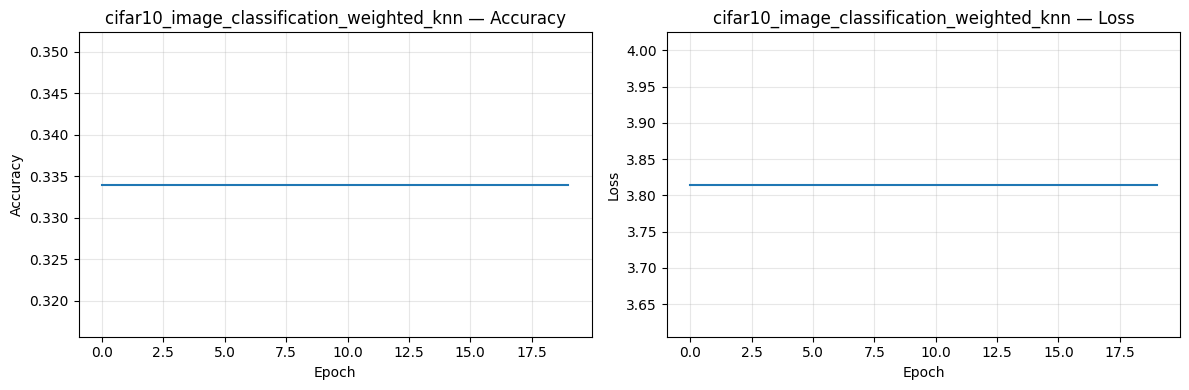

In [11]:
# Cell 5: Image Classification
from data.image_classification import load_data as load_image_data

X_train_img, X_test_img, y_train_img, y_test_img, num_classes_img = load_image_data()

img_loss, img_acc = run_experiment(
    X_train_img, X_test_img, y_train_img, y_test_img,
    input_dim=X_train_img.shape[1],
    num_classes=num_classes_img,
    experiment_name="cifar10_image_classification_weighted_knn",
    K=5,
    epochs=20
)

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[CIFAR-10] Extracting ResNet18 features...
[CIFAR-10] Train: torch.Size([4000, 512]), Test: torch.Size([1000, 512]), Classes: 10

Experiment: sentiment_analysis_weighted_knn
Input dim: 512
Classes: 10
K: 10
Epoch   0: Loss=0.7059, Acc=0.8170
Epoch   5: Loss=0.7059, Acc=0.8170
Epoch  10: Loss=0.7059, Acc=0.8170
Epoch  15: Loss=0.7059, Acc=0.8170
Epoch  19: Loss=0.7059, Acc=0.8170

Results (printed only, no files saved):
  Final Accuracy: 0.8170
  Final Loss:     0.7059


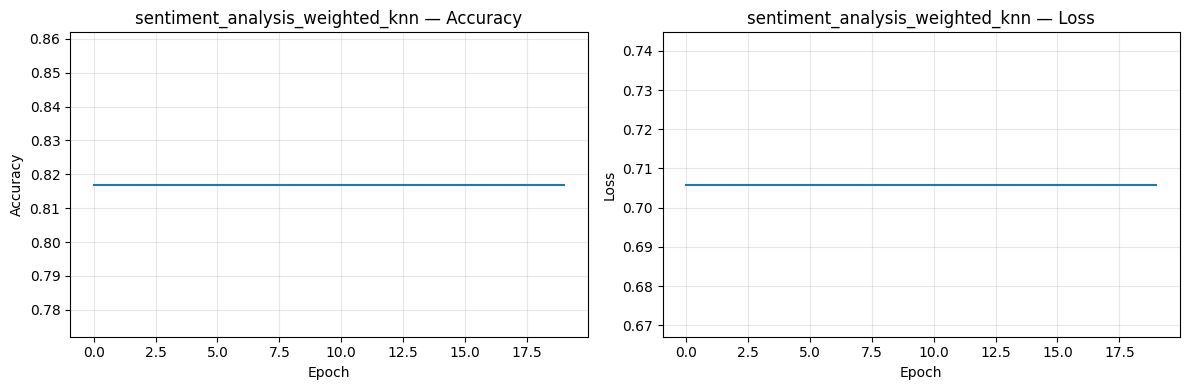

In [12]:
# Cell 6: Sentiment Analysis
from data.sentiment_analysis import load_data as load_sentiment_data

X_train_txt, X_test_txt, y_train_txt, y_test_txt, num_classes_txt = load_sentiment_data()

txt_loss, txt_acc = run_experiment(
    X_train_txt, X_test_txt, y_train_txt, y_test_txt,
    input_dim=X_train_txt.shape[1],
    num_classes=num_classes_txt,
    experiment_name="sentiment_analysis_weighted_knn",
    K=10,
    epochs=20
)

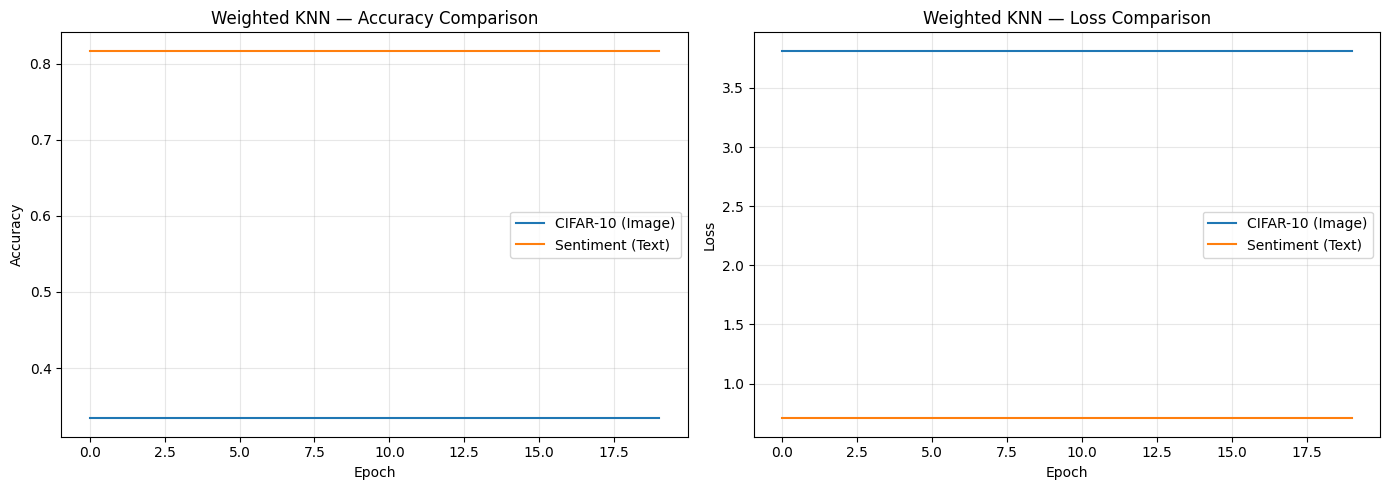

In [13]:
# Cell 7: Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(img_acc, label="CIFAR-10 (Image)")
axes[0].plot(txt_acc, label="Sentiment (Text)")
axes[0].set_title("Weighted KNN — Accuracy Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(img_loss, label="CIFAR-10 (Image)")
axes[1].plot(txt_loss, label="Sentiment (Text)")
axes[1].set_title("Weighted KNN — Loss Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Cell 8: Summary
print("\n" + "="*60)
print(f"{'Experiment':<35} {'Best Acc':>10} {'Final Acc':>10}")
print("="*60)
print(f"{'CIFAR-10 Image Classification':<35} {max(img_acc):>10.4f} {img_acc[-1]:>10.4f}")
print(f"{'Sentiment Analysis':<35} {max(txt_acc):>10.4f} {txt_acc[-1]:>10.4f}")
print("="*60)


Experiment                            Best Acc  Final Acc
CIFAR-10 Image Classification           0.3340     0.3340
Sentiment Analysis                      0.8170     0.8170
